# Train Object Detection Models (specifically, YOLO Models)

# Introduction
This notebook uses Ultralytics to train YOLOv11 object detection models with a custom dataset (Fruits). At the end of this Colab, you'll have a custom YOLO model that you can run on your PC, phone, or edge device like the Raspberry Pi.


# NVIDIA GPU Availability

Make sure you're using a GPU-equipped machine by going to "Runtime" -> "Change runtime type" in the top menu bar, and then selecting one of the GPU options in the Hardware accelerator section. Click Play on the following code block to verify that the NVIDIA GPU is present and ready for training.

In [ ]:
from google.colab import drive
# drive.mount('/content/drive')

In [1]:
# Change the runtime type from Runtime menu to GPU to run this cell and run the project on GPU generally.
!nvidia-smi

Thu Dec  4 09:17:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#1.&nbsp; Gather and Label Training Images

# 🖼️ Preparing Your Object Detection Dataset
Before you begin training an object detection model, you must gather and label the necessary images. A minimum of 200 images is recommended for a good proof-of-concept model.

Image Quality and Variety: The images used for training should be diverse:

They should feature the desired objects alongside random, distracting objects.

They must include a variety of backgrounds and lighting conditions to ensure the model generalizes well.

# 🛠️ Options for Gathering Images
You have two main methods for acquiring your dataset:

Build a Custom Dataset: Taking your own pictures and labeling them generally leads to the best model performance.

Use a Pre-made Dataset: You can find existing datasets on platforms like Roboflow Universe, Kaggle, or Google Images V7.

# 🏷️ Tools for Labeling
If you choose to create a custom dataset, you'll need a tool for labeling. Label Studio is a recommended choice. It is a free, open-source labeling tool that offers a straightforward workflow and advanced features.

If you labeled and exported your images using Label Studio, the result is a `project.zip` file. See image below.

This zip file contains four main components:

*   `images folder:` Holds the images themselves.
*   `labels folder:` Contains the annotations/labels in the YOLO format.
*   `classes.txt:` A label map file listing all the defined classes.

*   `notes.json:` A file with Label Studio-specific information that can generally be ignored.

If your dataset comes from a different source (like Roboflow Universe) or was labeled with another tool, you must ensure the files are arranged into this same folder structure for consistency.

Example of a Fruit image labeled with Label Studio.


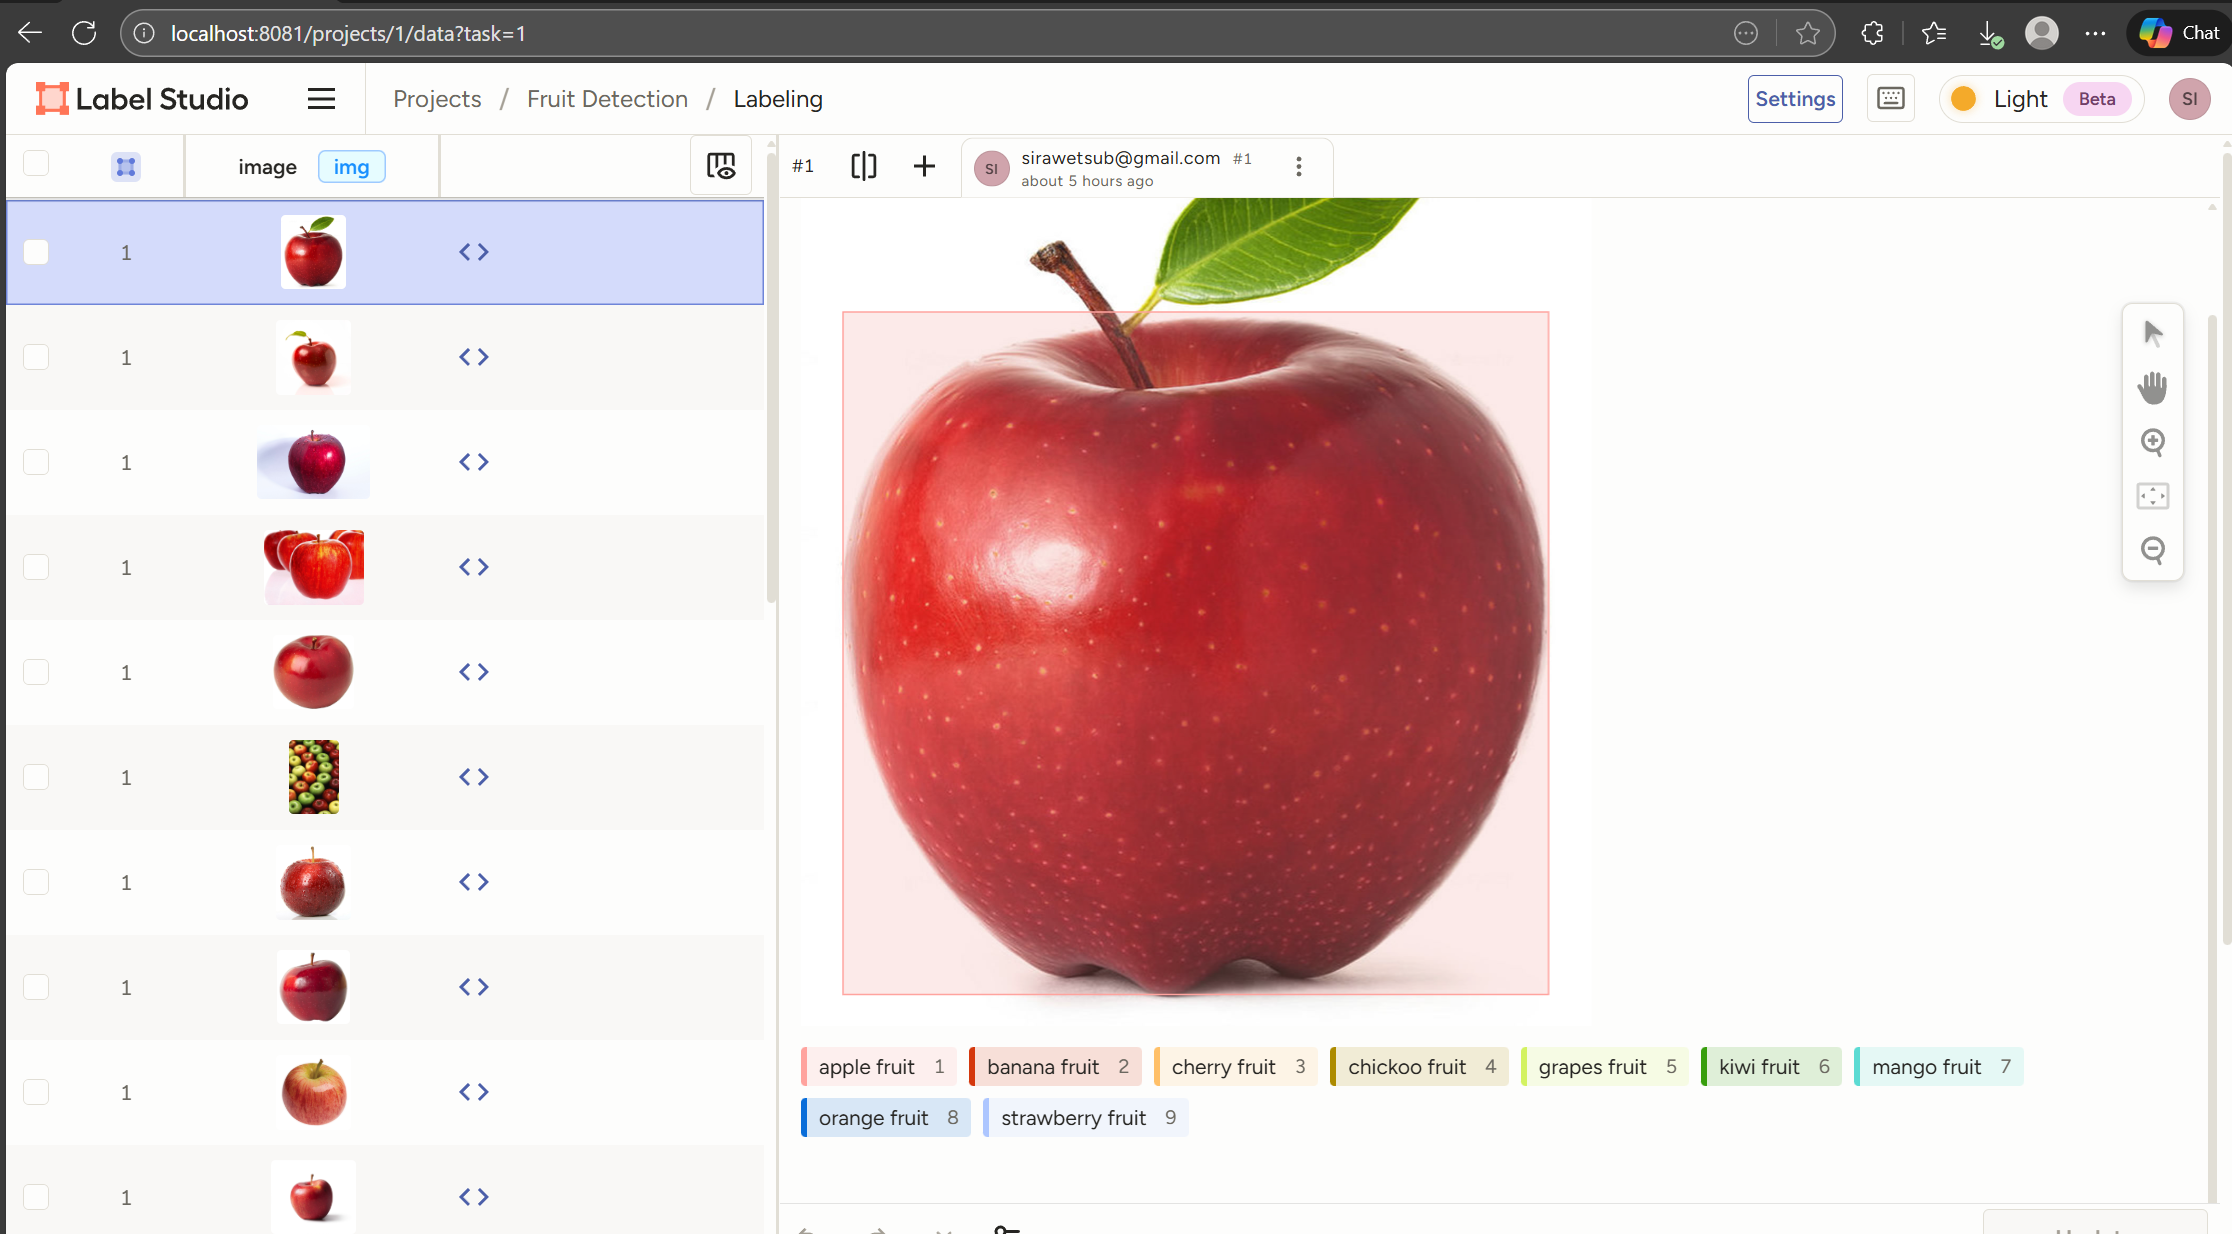

In [2]:
from IPython.display import Image, display
print("Example of a Fruit image labeled with Label Studio.")
image_path = 'Label Studio Screenshot 2025-12-02 235943.png'

display(Image(filename=image_path, height=300))



A downloaded folder structure of the labelled data using Label Studio.


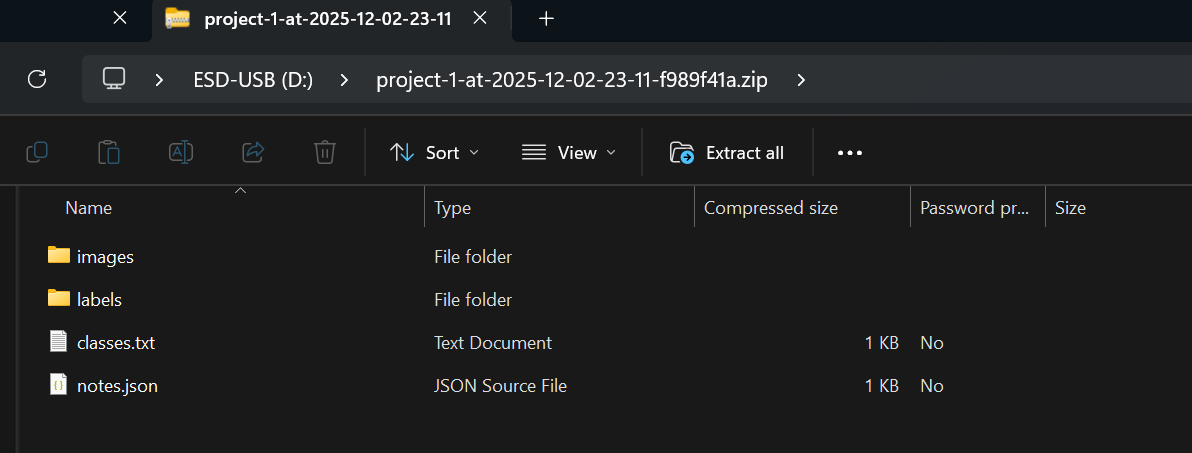

In [3]:
from IPython.display import Image, display
print("A downloaded folder structure of the labelled data using Label Studio.")
image_path = 'Screenshot 2025-12-02 235742.png'

display(Image(filename=image_path, height=300))

#2.&nbsp; Upload Image Dataset and Prepare Training Data

Next, we will upload the dataset and get it ready for YOLO model training. This preparation involves splitting the dataset into train and validation sets and automatically creating the necessary configuration file for training.

# 💾 2.1 Upload Images
The first step is to transfer your dataset, which should be compressed as a `labelled_data.zip` file, into the Colab environment.

Option 1: Using the Google Colab Interface
You can upload the `labelled_data.zip` file directly through the Colab user interface:

Click the "Files" icon (usually on the left sidebar).

Click the "Upload to session storage" icon (an arrow pointing up).

Select the `labelled_data.zip` file from your local computer to upload it to the Colab instance.

The next step is to unzip this file and create the necessary training and validation folders to organize the images for model training. Execute the provided code block to unzip the data.

📂 Splitting Data into Training and Validation Sets
After confirming the presence of your data.zip file, you need to execute the code to:

Unzip `labelled_data.zip` to extract the images and labels.

Create specific folders (like train/ and val/) where the images will be moved for the next step.

In [6]:
# Unzip images to a custom data folder
!unzip -q /content/labelled_data.zip -d /content/custom_data

Ultralytics models require a specific directory structure for storing training data.

The root folder must be named "data," and it contains two critical subfolders:

`Train:` This folder holds the actual images used to train the model. During each training epoch, the model processes these images, and the training algorithm adjusts the network's internal weights to learn the patterns in the data.

`Validation (Val):` These images are reserved for checking the model's performance after each training epoch. They help ensure the model is learning general patterns and not just memorizing the training data.

Folder Organization
Inside both the Train and Validation folders, you must have two directories:

A images folder for the image files.

A labels folder for the corresponding annotation files.

Dataset Splitting
We've written a Python script that automates this setup by:

Creating the necessary folder structure.

Randomly moving 90% of your original dataset into the train split.

Randomly moving the remaining 10% into the validation split.

Run the following code block to download and execute the script.

In [7]:
import os
Root_Folder = "custom_data"
label_sub_Folder = "labels"
images_sub_Folder = "images"
labels_txt = [f for f in os.listdir(f"{Root_Folder}/{label_sub_Folder}")]
DATA = []
for i in labels_txt:
  with open(f"{Root_Folder}/{label_sub_Folder}/{i}", 'r') as l:
    label = l.read()[0]
    map_data = {
                "image_file_name": i.split(".txt")[0] ,
                "label": label
               }
    DATA.append(map_data)

In [8]:
import pandas as pd
images_df = pd.DataFrame(DATA)
images_df

,image_file_name,label
0,2a91f717-Image_23,2
1,c7b40be3-Image_22,6
2,bd9c481c-Image_32,2
3,6b41ae98-Image_33,8
4,47466cba-Image_39,6
...,...,...
353,0a8ecb7f-Image_16,3
354,7bd2e96e-Image_19,4
355,455433ad-Image_8,2
356,bf051692-Image_6,5


In [9]:
from sklearn.model_selection import train_test_split
train, validate = train_test_split(images_df, stratify=images_df['label'], test_size=0.2)

In [10]:
train_img = [name for name in list(train.image_file_name)]
val_img = [name for name in list(validate.image_file_name)]
train_images = [img for img in os.listdir(f"{Root_Folder}/{images_sub_Folder}") if img.split(".")[0] in train_img]
validate_images = [img for img in os.listdir(f"{Root_Folder}/{images_sub_Folder}") if img.split(".")[0] in val_img]
print(len(train_images), len(validate_images))

train_labels = [img for img in os.listdir(f"{Root_Folder}/{label_sub_Folder}") if img.split(".")[0] in train_img]
validate_labels = [img for img in os.listdir(f"{Root_Folder}/{label_sub_Folder}") if img.split(".")[0] in val_img]


# Create the target directory if it doesn't exist
!mkdir -p /content/train/images
!mkdir -p /content/validation/images

!mkdir -p /content/train/labels
!mkdir -p /content/validation/labels

for image_file in train_images:

    source_path = f"{Root_Folder}/{images_sub_Folder}/{image_file}"
    command = f"cp '{source_path}' /content/train/images"
    !{command}

print(f"Successfully attempted to copy {len(train_images)} images to /content/train/images.")

for image_file in validate_images:

    source_path = f"{Root_Folder}/{images_sub_Folder}/{image_file}"
    command = f"cp '{source_path}' /content/validation/images"
    !{command}

print(f"Successfully attempted to copy {len(validate_images)} images to /validation/images.")


for label_file in train_labels:

    source_path = f"{Root_Folder}/{label_sub_Folder}/{label_file}"
    command = f"cp '{source_path}' /content/train/labels"
    !{command}

print(f"Successfully attempted to copy {len(train_labels)} labels to /content/train/labels.")

for label_file in validate_labels:

    source_path = f"{Root_Folder}/{label_sub_Folder}/{label_file}"
    command = f"cp '{source_path}' /content/validation/labels"
    !{command}

print(f"Successfully attempted to copy {len(validate_labels)} labels to /validation/labels.")


286 72
Successfully attempted to copy 286 images to /content/train/images.
Successfully attempted to copy 72 images to /validation/images.
Successfully attempted to copy 286 labels to /content/train/labels.
Successfully attempted to copy 72 labels to /validation/labels.


#3.&nbsp; Install Requirements (Ultralytics)
To proceed, you need to install the Ultralytics Python library within this Google Colab environment. This specific library is what we'll use to train the YOLO model.

In [12]:
# !pip install ultralytics

#4.&nbsp;⚙️ Setting Up Training Configuration
Before starting the training process, you must create an Ultralytics training configuration file (a `YAML file`).

This configuration file is essential because it tells the system:

*   The location of your training and validation datasets.

*   The defined classes (categories) for the model.

A sample structure for this file is available <a href="https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml">here</a> if you need a reference.

To automatically create the necessary `data.yaml` configuration file, run the code block provided below.

📝 Key Requirement: `classes.txt`
Crucially, ensure you have a label map file named `classes.txt` located in the `custom_data/` folder.

If you used Label Studio or a pre-existing dataset, this file should already be present.

If you created your dataset using a different method, you might need to manually create the `classes.txt` file (refer to the documentation for the correct formatting <a href="https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/doc/classes.txt">here</a>).


In [13]:
# Install PyYAML if it's not already installed in your Colab environment
# Note: It is usually pre-installed. Uncomment the line below if you run into an error.
# !pip install pyyaml -qq

import yaml
import os
import sys

def create_ultralytics_data_yaml(classes_file_path: str, output_yaml_path: str, base_data_path: str = '/content/') -> None:
    """
    Automatically generates the Ultralytics data.yaml configuration file.

    Args:
        classes_file_path: Path to the classes.txt file containing class names (one per line).
        output_yaml_path: The destination path for the generated data.yaml file.
        base_data_path: The base path where the 'train' and 'validation' folders are located.
    """

    # --- 1. Read class.txt to get class names ---
    if not os.path.exists(classes_file_path):
        print(f'🚨 Error: classes.txt file not found at {classes_file_path}')
        print('Please create a classes.txt label map and place it in the specified location.')
        return

    class_names = []
    try:
        with open(classes_file_path, 'r') as f:
            for line in f.readlines():
                # Strip whitespace and ignore empty lines
                stripped_line = line.strip()
                if stripped_line:
                    class_names.append(stripped_line)
    except Exception as e:
        print(f"Error reading {classes_file_path}: {e}", file=sys.stderr)
        return

    num_classes = len(class_names)
    if num_classes == 0:
        print(f"⚠️ Warning: No class names found in {classes_file_path}. YAML file will reflect 0 classes.")

    # --- 2. Create data dictionary ---
    # Ultralytics (YOLOv8, etc.) convention:
    # 'path': root directory of the dataset
    # 'train': relative path from 'path' to training images
    # 'val': relative path from 'path' to validation images
    # 'nc': number of classes
    # 'names': list of class names
    data_config = {
        'path': base_data_path,
        'train': 'train/images',
        'val': 'validation/images',
        'nc': num_classes,
        'names': class_names
    }

    # --- 3. Write data to YAML file ---
    try:
        with open(output_yaml_path, 'w') as f:
            # Use sort_keys=False to keep the dict order (path, train, val, nc, names)
            yaml.dump(data_config, f, sort_keys=False)
        print(f'✅ Successfully created config file at {output_yaml_path}')
        print(f'   Number of classes found: {num_classes}')
    except Exception as e:
        print(f"Error writing to {output_yaml_path}: {e}", file=sys.stderr)


# ==============================================================================
# Execution Block
# ==============================================================================

# Define paths for a typical Colab/YOLO project setup
CLASSES_FILE_PATH = '/content/custom_data/classes.txt'
OUTPUT_YAML_PATH = '/content/data.yaml'

# Call the function to generate the config file
create_ultralytics_data_yaml(CLASSES_FILE_PATH, OUTPUT_YAML_PATH)

# Display the contents of the generated YAML file for verification
print('\n--- Contents of generated data.yaml ---\n')
# The '!' runs a shell command in Colab/Jupyter
!cat {OUTPUT_YAML_PATH}

✅ Successfully created config file at /content/data.yaml
   Number of classes found: 9

--- Contents of generated data.yaml ---

path: /content/
train: train/images
val: validation/images
nc: 9
names:
- apple fruit
- banana fruit
- cherry fruit
- chickoo fruit
- grapes fruit
- kiwi fruit
- mango fruit
- orange fruit
- strawberry fruit


# 5.&nbsp;Train Model

## 5.1 Training Parameters
Now that the data is organized and the config file is created, we're ready to start training! First, there are a few important parameters to decide on. Visit an article on [Training YOLO Models Locally](https://www.ejtech.io/learn/train-yolo-models) to learn more about these parameters and how to choose them.

**Model architecture & size (`model`):**

There are several YOLO11 models sizes available to train, including `yolo11n.pt`, `yolo11s.pt`, `yolo11m.pt`, `yolo11l.pt`, and `yolo11xl.pt`. Larger models run slower but have higher accuracy, while smaller models run faster but have lower accuracy. I made a brief YouTube video that compares performance of different YOLO models on a Raspberry Pi 5 and a laptop with a RTX 4050 GPU, [check it out here to get a sense of their speed accuracy](https://youtu.be/_WKS4E9SmkA). If you aren't sure which model size to use, `yolo11s.pt` is a good starting point.

You can also train YOLOv8 or YOLOv5 models by substituting `yolo11` for `yolov8` or `yolov5`.


**Number of epochs (`epochs`)**

In machine learning, one “epoch” is one single pass through the full training dataset. Setting the number of epochs dictates how long the model will train for. The best amount of epochs to use depends on the size of the dataset and the model architecture. If your dataset has less than 200 images, a good starting point is 60 epochs. If your dataset has more than 200 images, a good starting point is 40 epochs.


**Resolution (`imgsz`)**

Resolution has a large impact on the speed and accuracy of the model: a lower resolution model will have higher speed but less accuracy. YOLO models are typically trained and inferenced at a 640x640 resolution. However, if you want your model to run faster or know you will be working with low-resolution images, try using a lower resolution like 480x480.


## 5.2 Run Training!

Run the following code block to begin training. If you want to use a different model, number of epochs, or resolution, change `model`, `epochs`, or `imgsz`.

In [14]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=60 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

The training algorithm will parse the images in the training and validation directories and then start training the model. At the end of each training epoch, the program runs the model on the validation dataset and reports the resulting mAP, precision, and recall. As training continues, the mAP should generally increase with each `epoch`. Training will end once it goes through the number of epochs specified by epochs.

> **NOTE:** Make sure to allow training to run to completion, because an optimizer runs at the end of training that strips out unneeded layers from the model.

The best trained model weights will be saved in `content/runs/detect/train/weights/best.pt`. Additional information about training is saved in the `content/runs/detect/train` folder, including a `results.png` file that shows how loss, precision, recall, and mAP progressed over each epoch.

#6.&nbsp;Test Model

The model has been trained; now it's time to test it! The commands below run the model on the images in the validation folder and then display the results for the first 10 images. This is a good way to confirm your model is working as expected. Click Play on the blocks below to see how your model performs.

In [16]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=validation/images save=True

Ultralytics 8.3.234 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs

image 1/72 /content/validation/images/00e83081-Image_37.jpeg: 384x640 1 mango fruit, 61.9ms
image 2/72 /content/validation/images/04940c0b-Image_9.jpg: 512x640 1 kiwi fruit, 58.4ms
image 3/72 /content/validation/images/0682bf3a-Image_37.png: 480x640 1 banana fruit, 57.9ms
image 4/72 /content/validation/images/095d8a36-Image_30.jpg: 384x640 1 strawberry fruit, 11.6ms
image 5/72 /content/validation/images/098c7b4a-Image_33.jpg: 448x640 8 banana fruits, 57.9ms
image 6/72 /content/validation/images/0def9a69-Image_9.jpg: 416x640 1 grapes fruit, 59.6ms
image 7/72 /content/validation/images/118504c9-Image_20.jpg: 416x640 1 grapes fruit, 12.0ms
image 8/72 /content/validation/images/154e5f8f-Image_37.jpg: 544x640 1 chickoo fruit, 64.1ms
image 9/72 /content/validation/images/20163664-Image_25.jpg: 384x640 3 apple fruits, 11.7ms
im

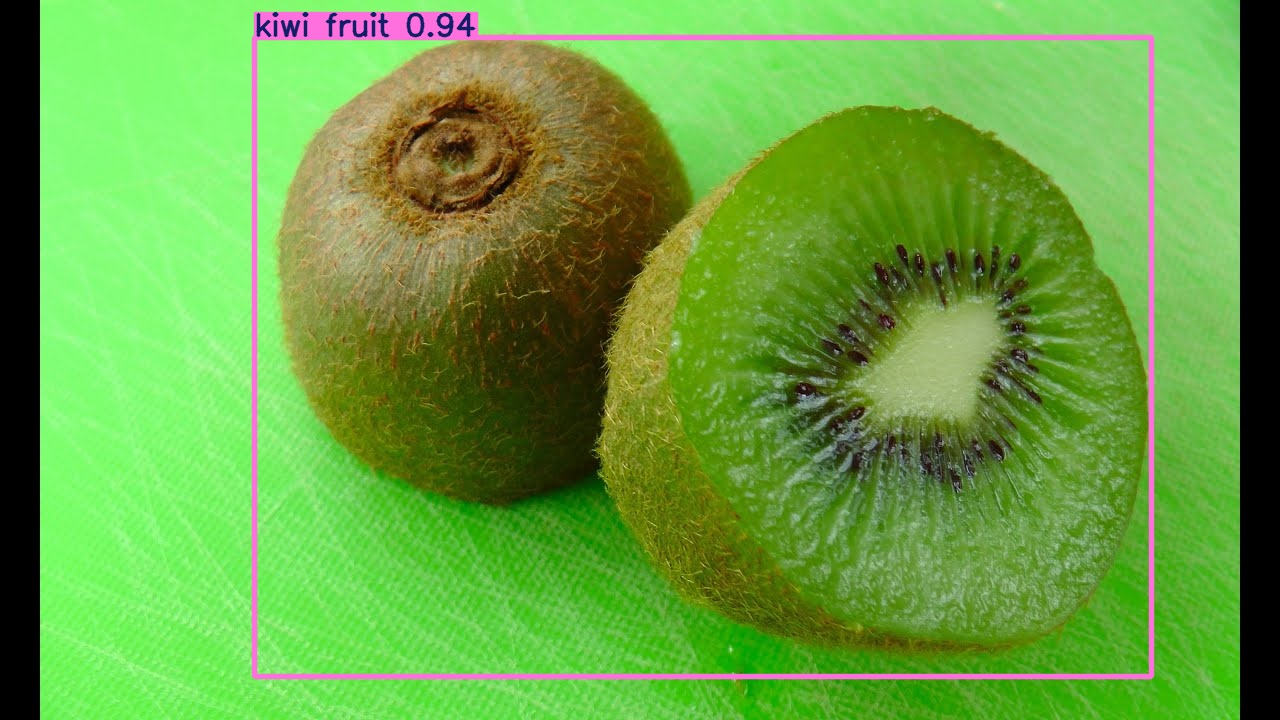

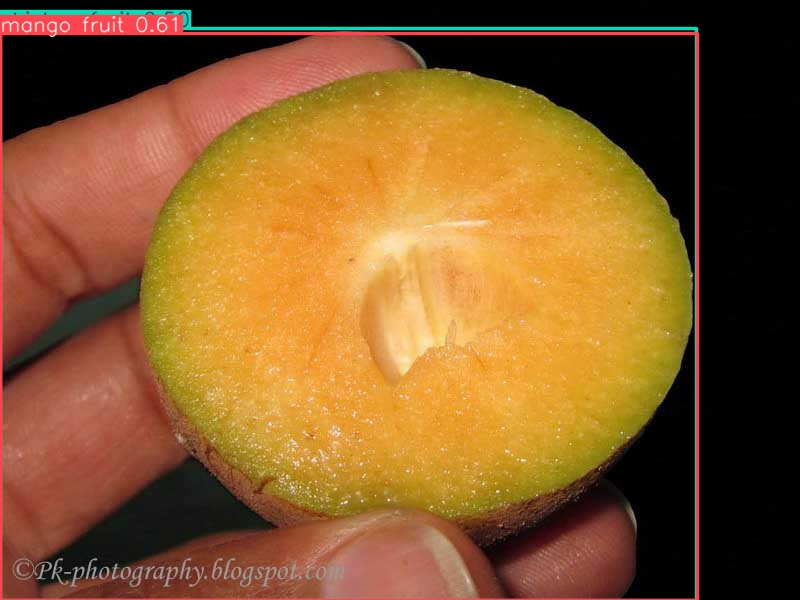

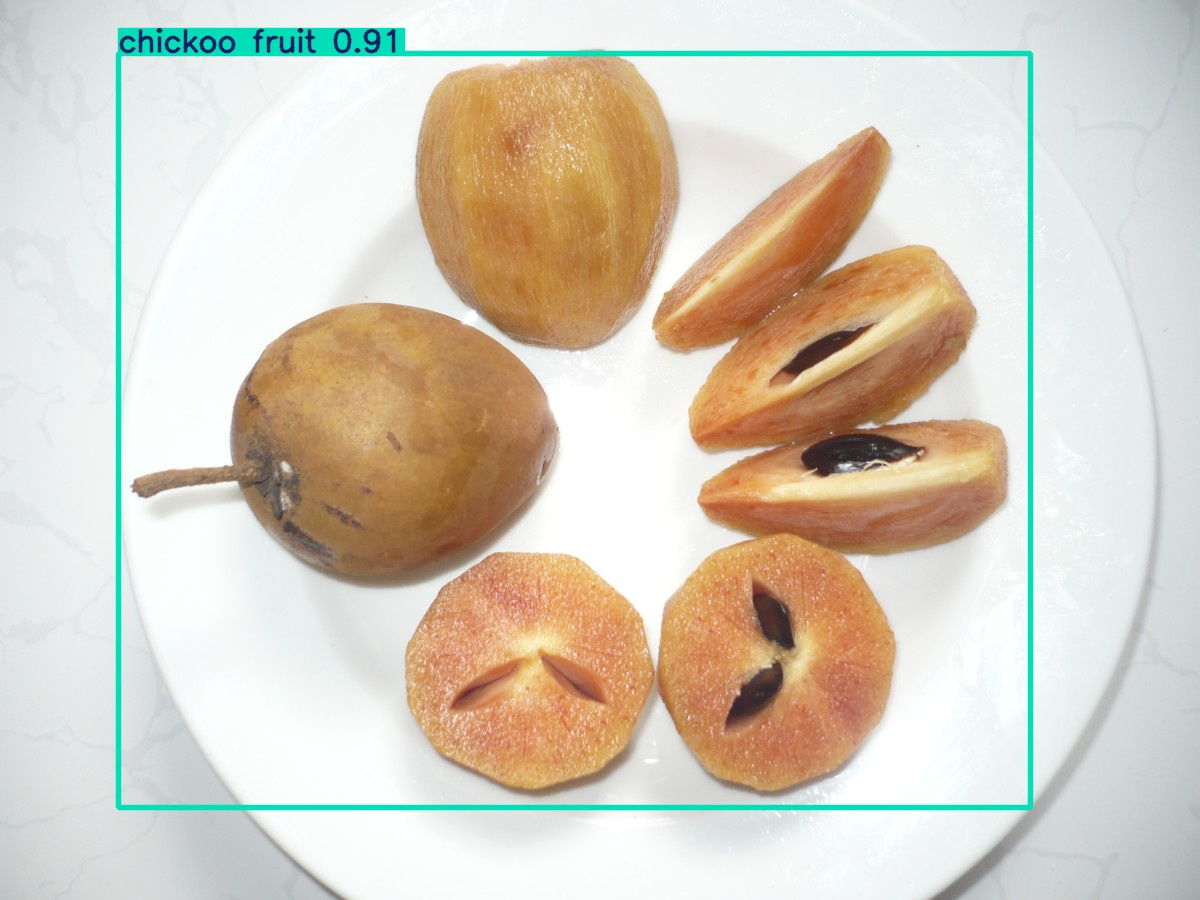

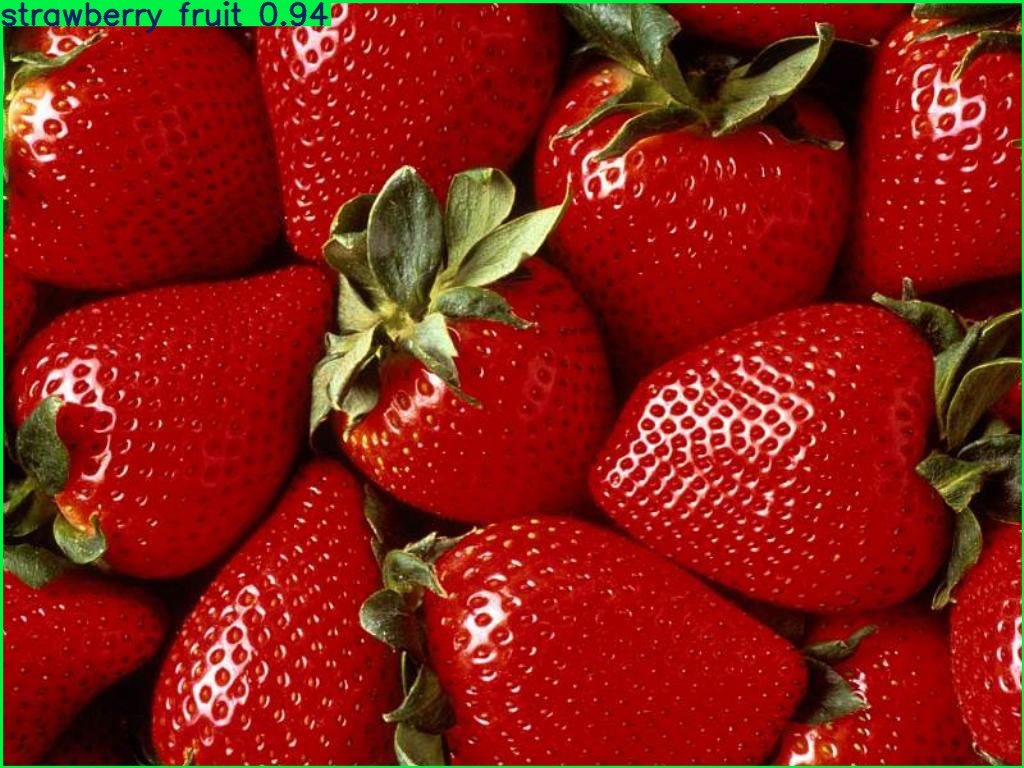

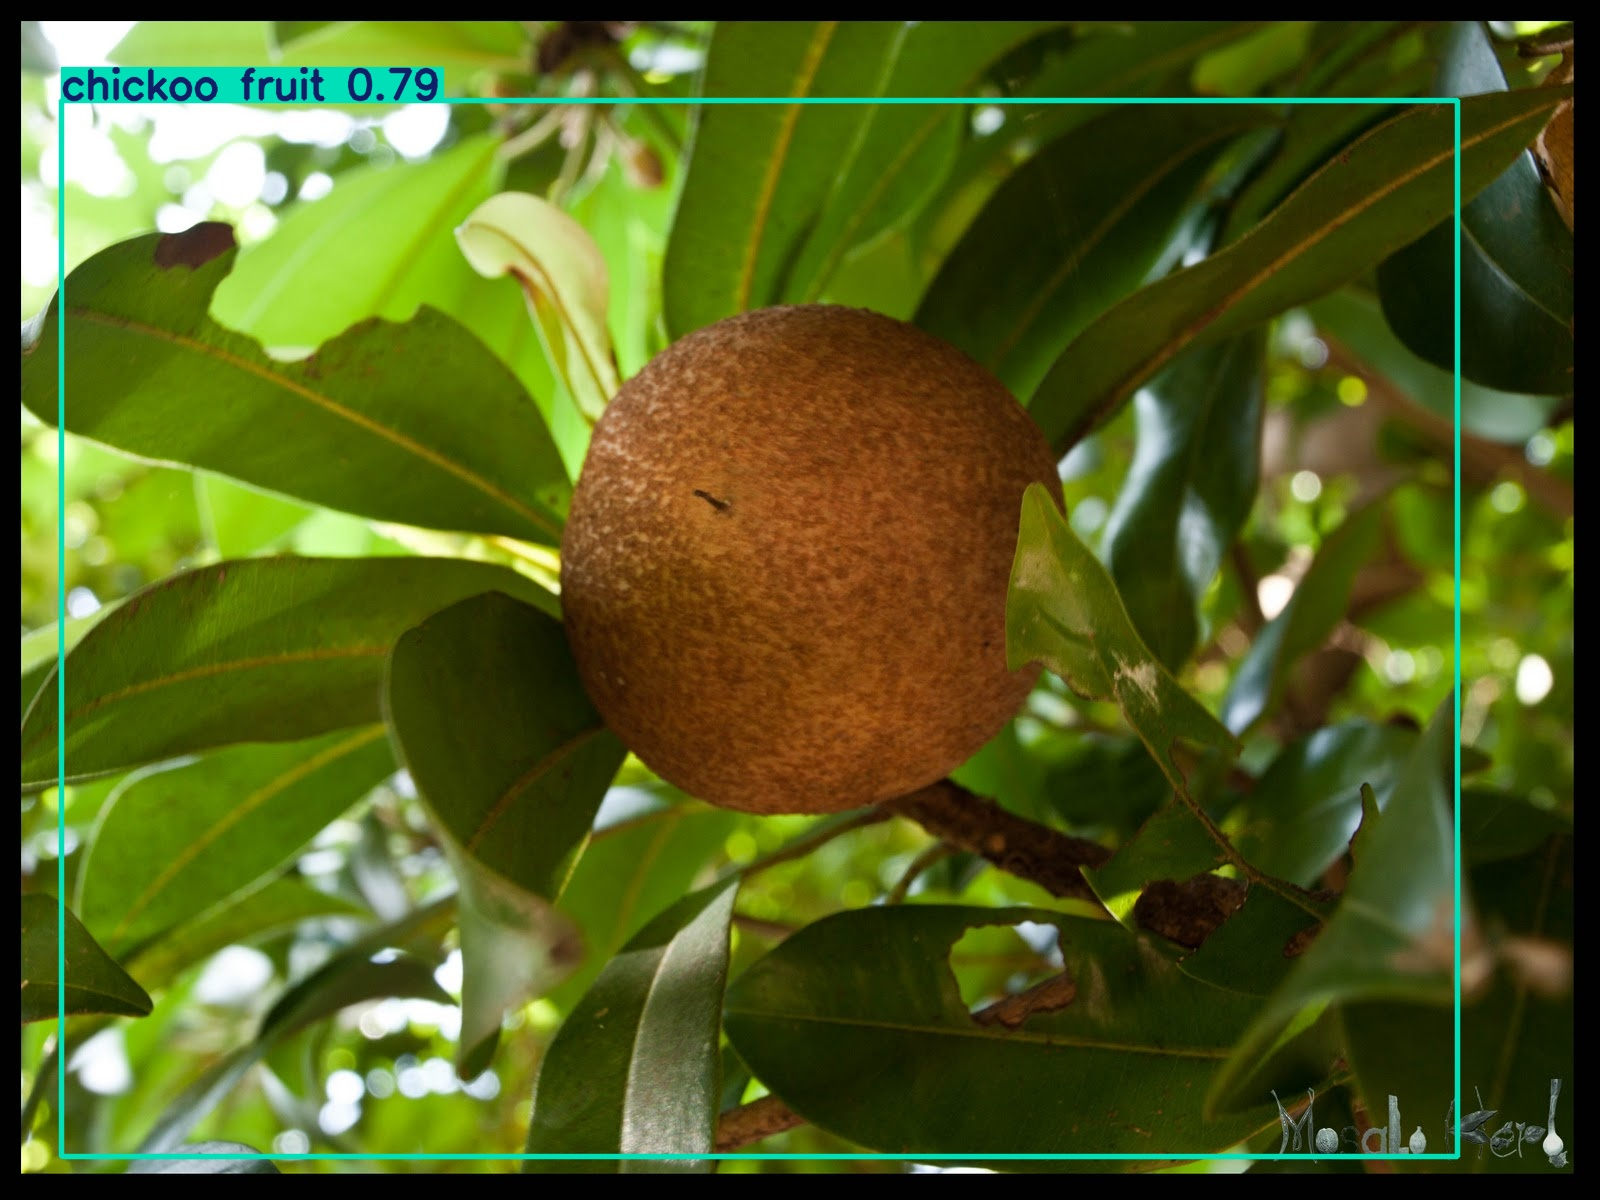

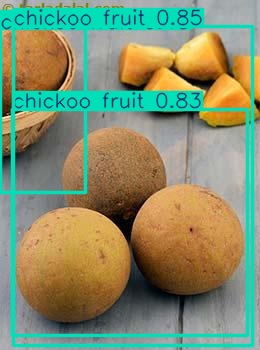

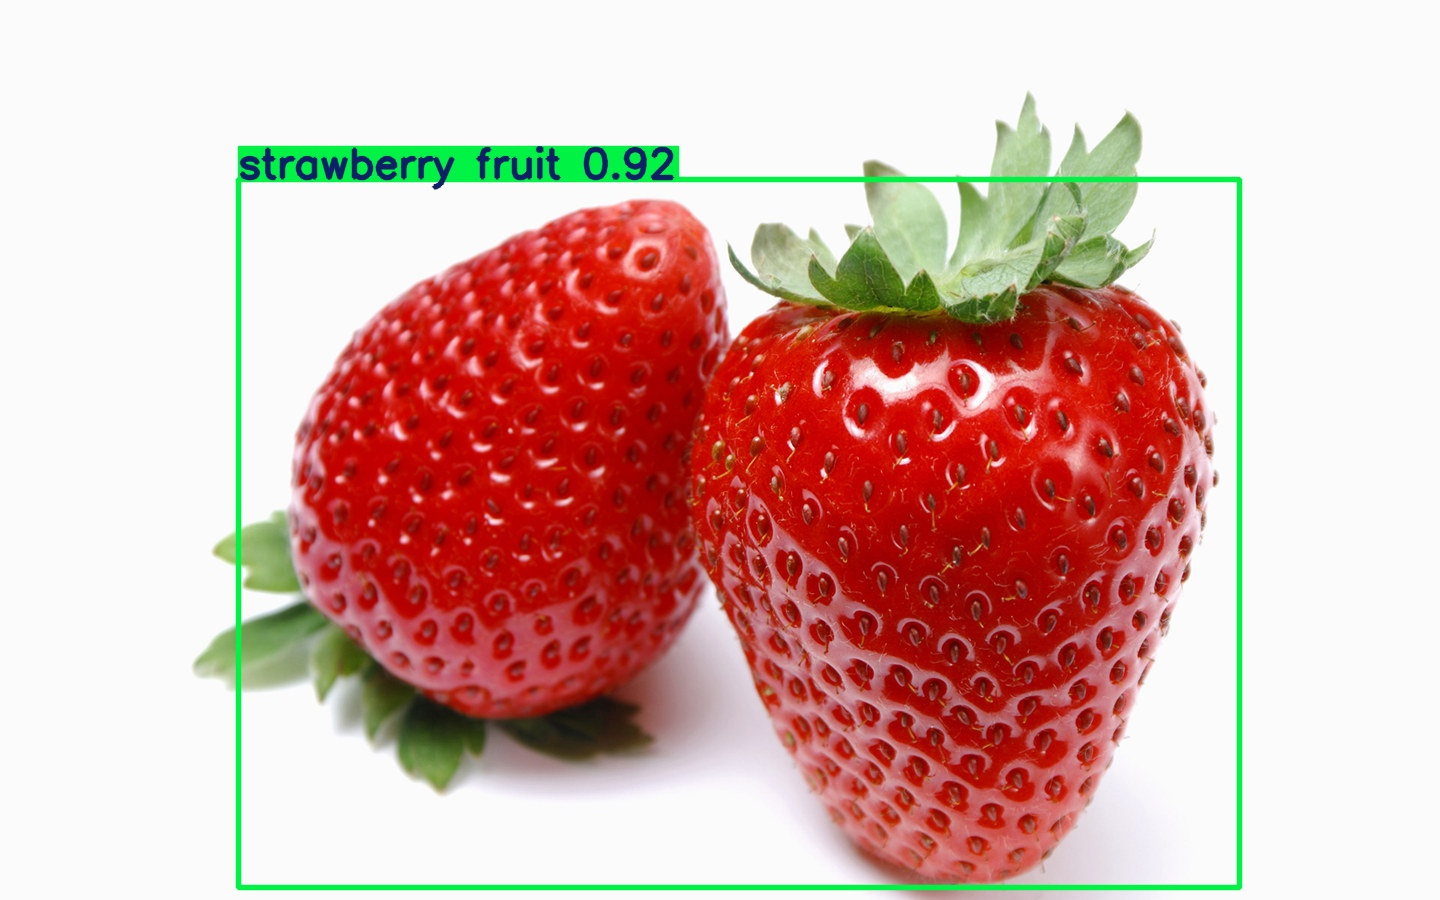

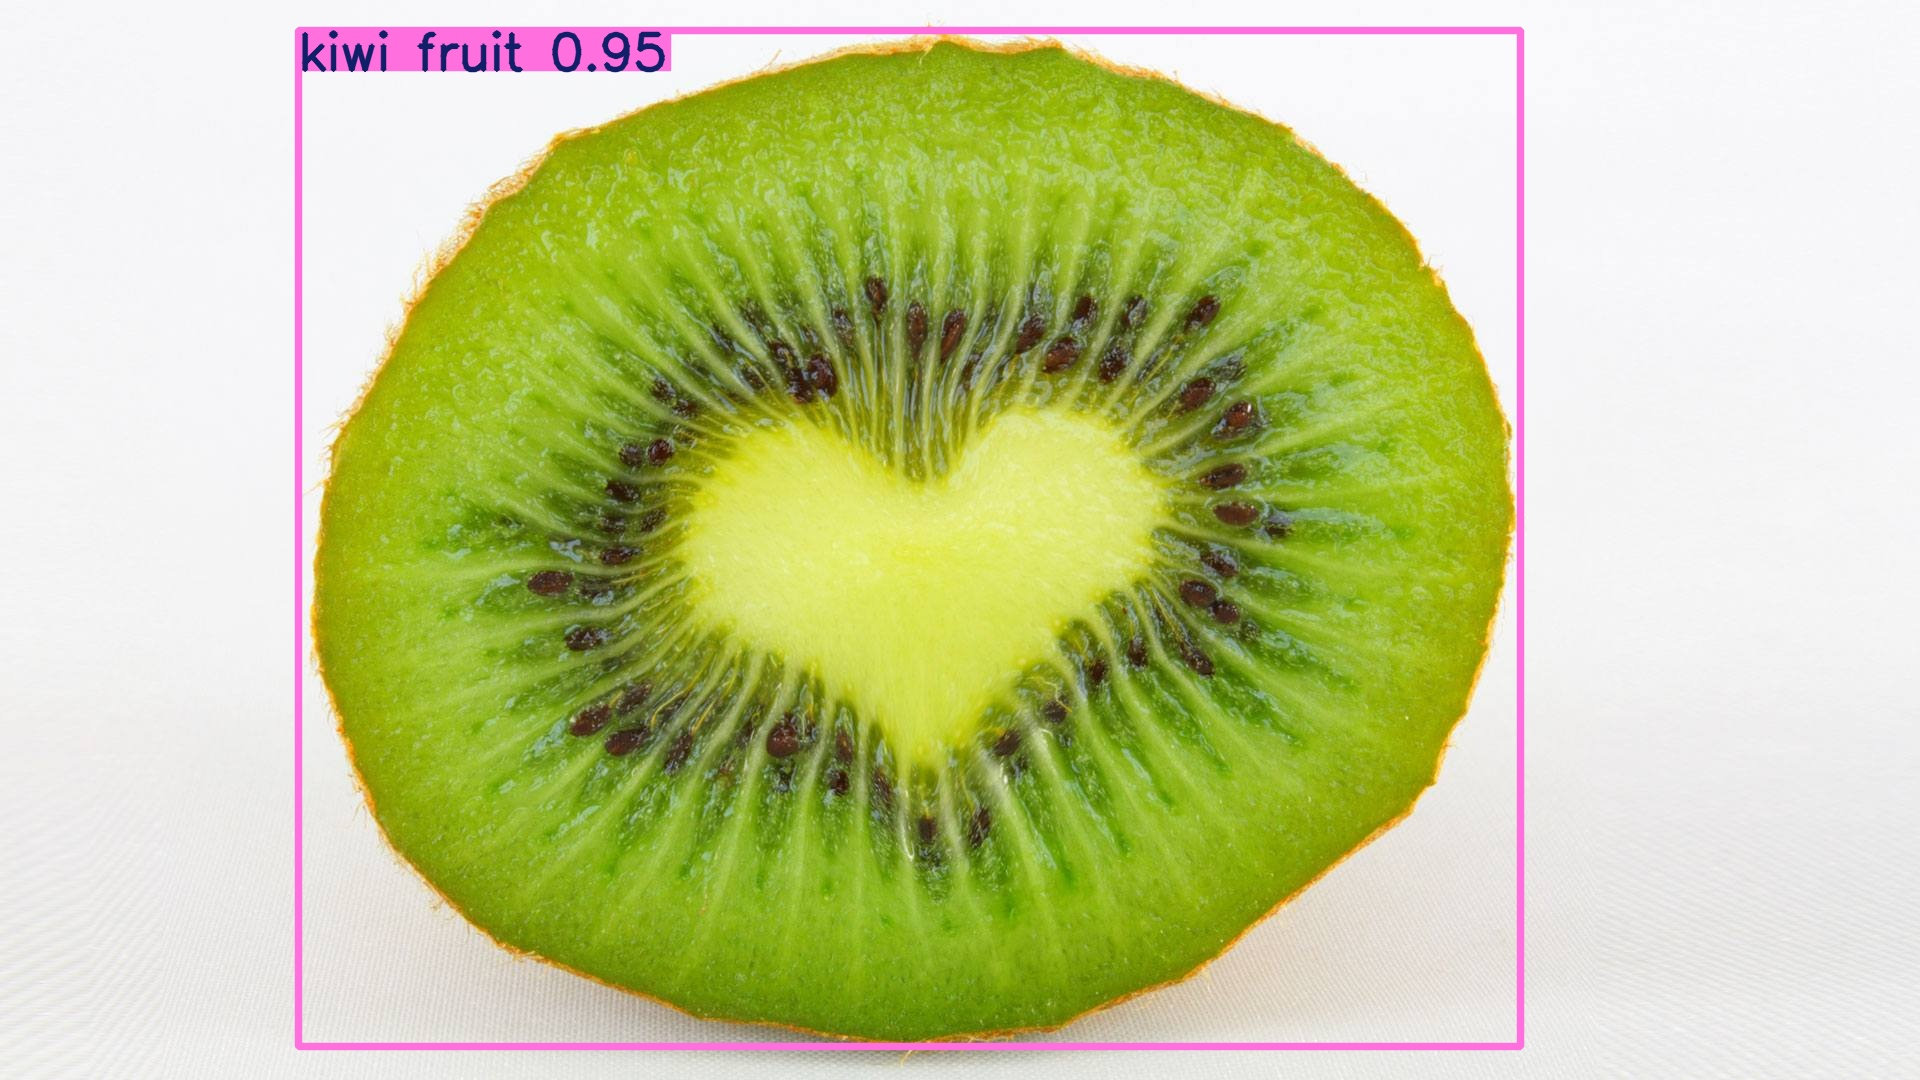

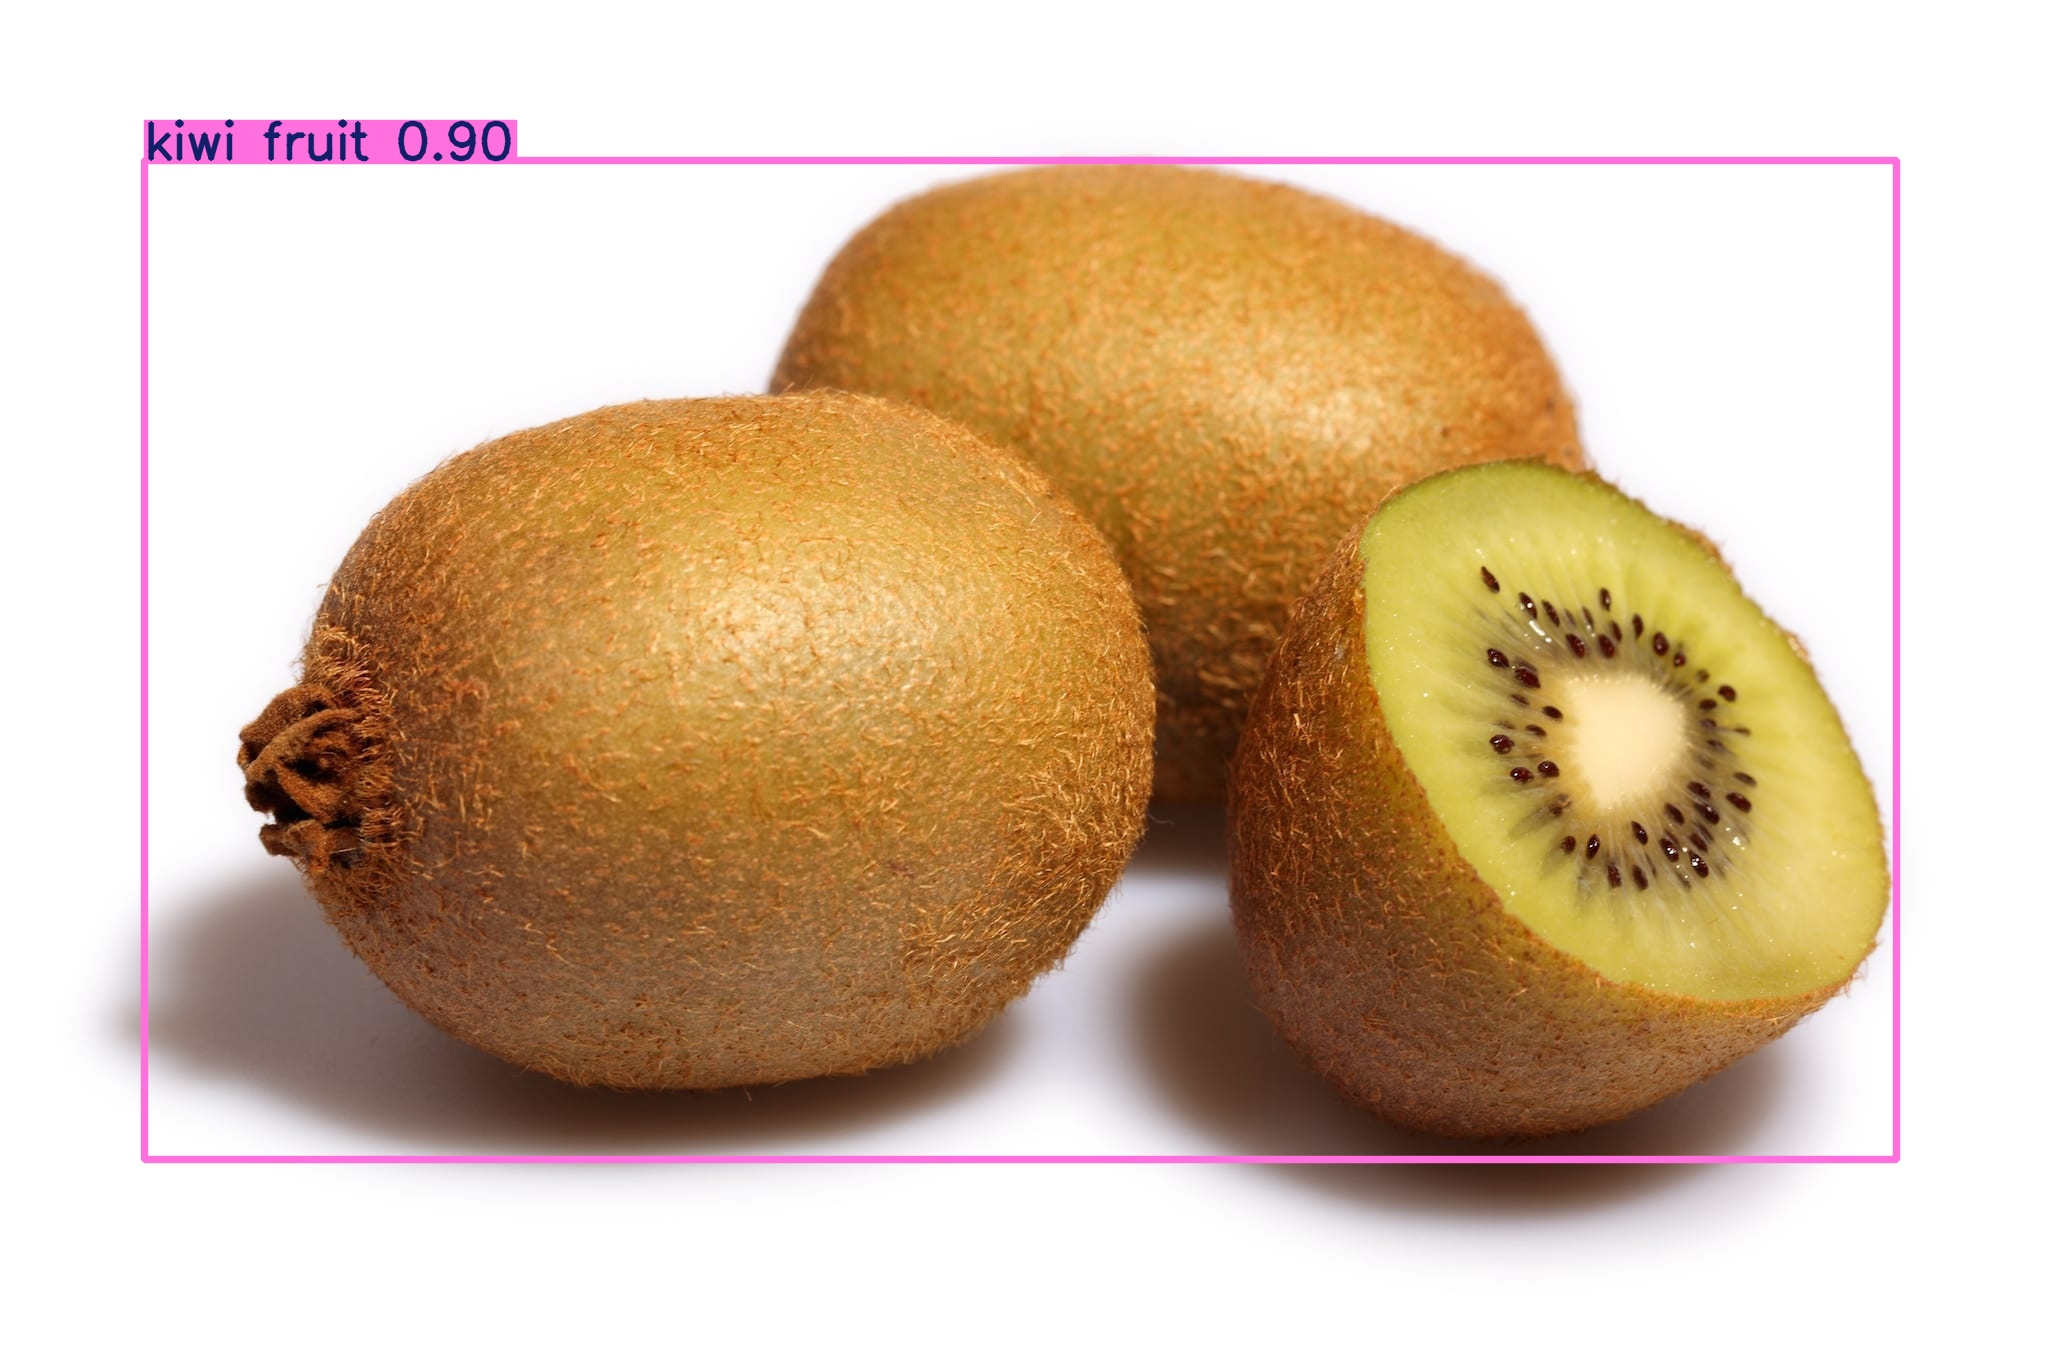

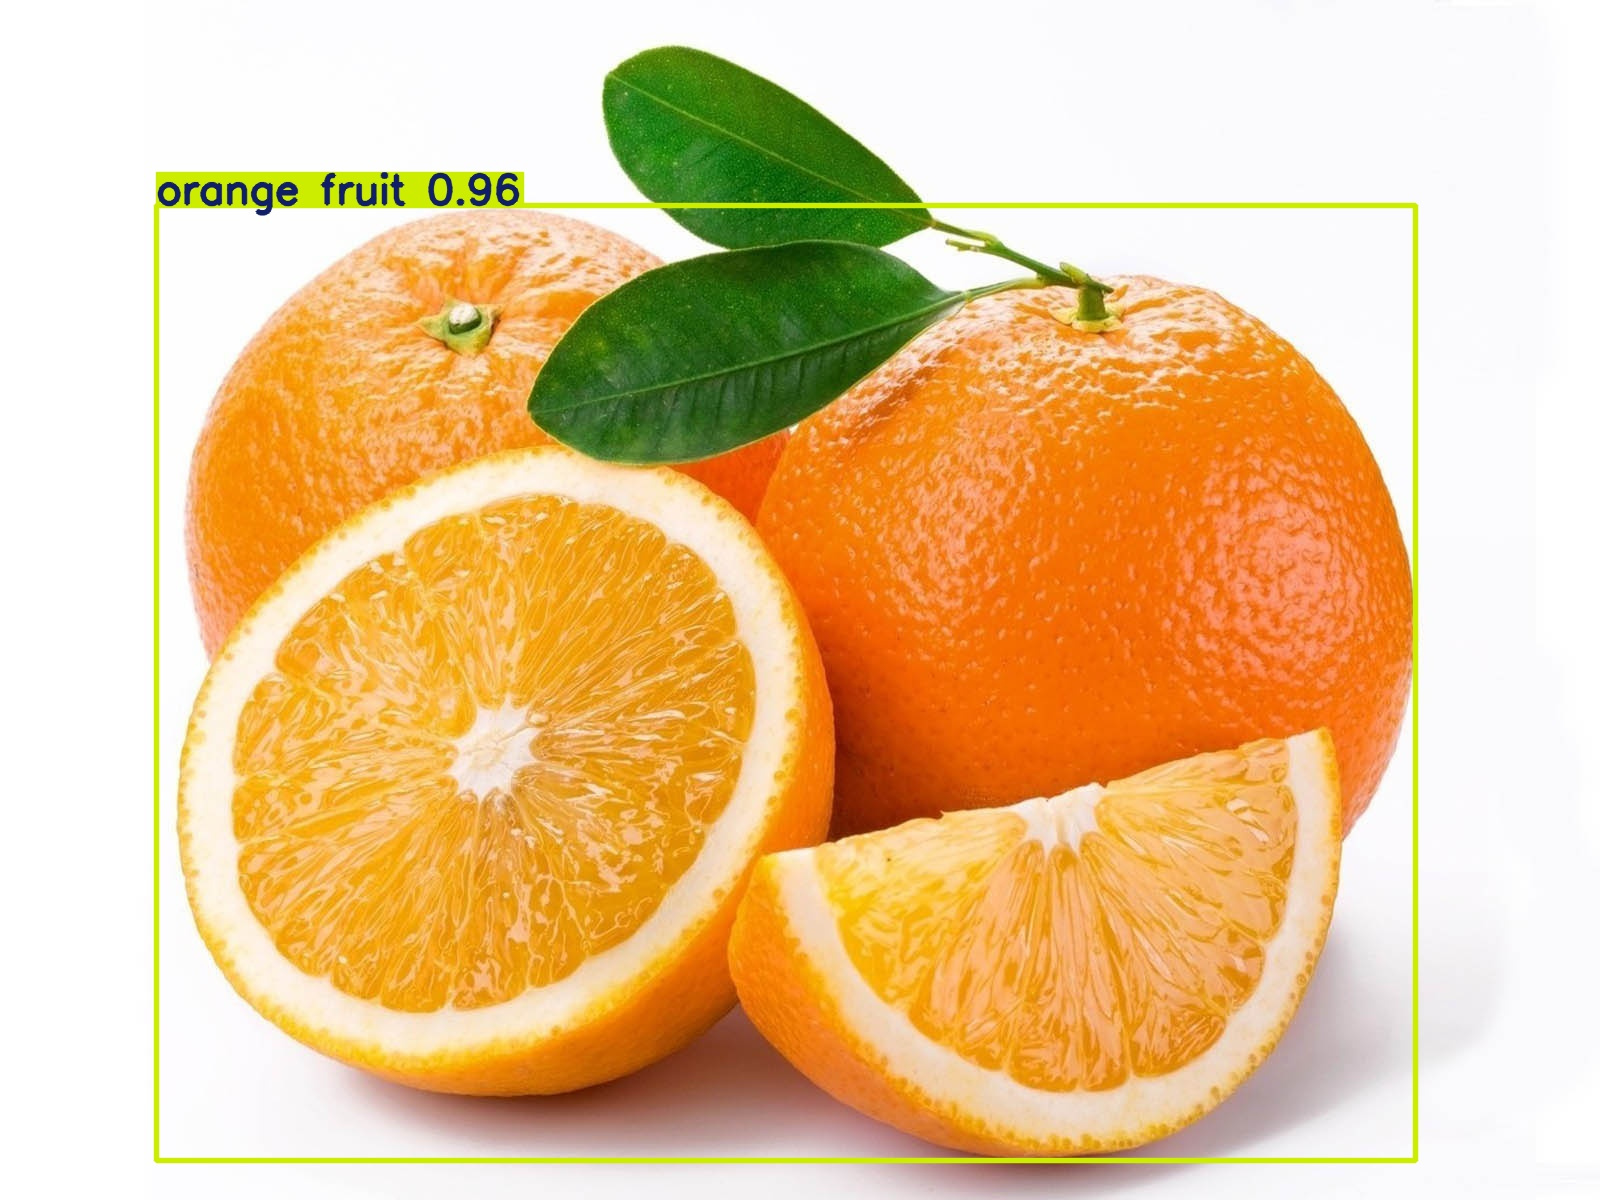

In [17]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

The model should draw a box around each object of interest in each image. If it isn't doing a good job of detecting objects, here are a few tips:

1. Double-check your dataset to make sure there are no labeling errors or conflicting examples.
2. Increase the number of epochs used for training.
3. Use a larger model size (e.g. `yolo11l.pt`).
4. Add more images to the training dataset. See my [dataset video](https://www.youtube.com/watch?v=v0ssiOY6cfg) for tips on how to capture good training images and improve accuracy.

You can also run the model on video files or other images images by uploading them to this notebook and using the above `!yolo detect predict` command, where `source` points to the location of the video file, image, or folder of images. The results will be saved in `runs/detect/predict`.

Drawing boxes on images is great, but it isn't very useful in itself. It's also not very helpful to just run this models inside a Colab notebook: it's easier if we can just run it on a local computer. Continue to the next section to see how to download your newly trained model and run it on a local device.

#7.&nbsp;Deploy Model

Now that your custom model has been trained, it's ready to be downloaded and deployed in an application! YOLO models can run on a wide variety of hardware, including PCs, embedded systems, and phones. Ultralytics makes it easy to convert the YOLO models to various formats (tflite, onnx, etc.) and deploy them in a variety of environments.

This section shows how to download the model and provides links to instructions for deploying it on your PC and edge devices like the Raspberry Pi.

## 7.1 Download YOLO Model

First, zip and download the trained model by running the code blocks below.

The code creates a folder named `my_model`, moves the model weights into it, and renames them from `best.pt` to `my_model.pt`. It also adds the training results in case you want to reference them later. It then zips the folder as `my_model.zip`.

In [18]:
# Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.pt
!cp -r /content/runs/detect/train /content/my_model

# Zip into "my_model.zip"
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model
  adding: my_model.pt (deflated 8%)
  adding: train/ (stored 0%)
  adding: train/val_batch2_labels.jpg (deflated 11%)
  adding: train/train_batch2.jpg (deflated 5%)
  adding: train/train_batch901.jpg (deflated 15%)
  adding: train/args.yaml (deflated 53%)
  adding: train/train_batch902.jpg (deflated 14%)
  adding: train/confusion_matrix.png (deflated 23%)
  adding: train/labels.jpg (deflated 28%)
  adding: train/results.csv (deflated 61%)
  adding: train/results.png (deflated 6%)
  adding: train/val_batch2_pred.jpg (deflated 11%)
  adding: train/BoxR_curve.png (deflated 9%)
  adding: train/confusion_matrix_normalized.png (deflated 19%)
  adding: train/val_batch1_pred.jpg (deflated 14%)
  adding: train/BoxF1_curve.png (deflated 6%)
  adding: train/train_batch900.jpg (deflated 19%)
  adding: train/val_batch0_pred.jpg (deflated 13%)
  adding: train/BoxPR_curve.png (deflated 13%)
  adding: train/val_batch1_labels.jpg (deflated 14%)
  adding: train/train_batch1.jpg (deflat

In [19]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7.2 Deploy YOLO Model on Local Devices

Next, we'll take our downloaded model and run it on a local device. This section provides instructions showing how to deploy YOLO models on various devices.

I wrote a basic Python script, `yolo_detect.py`, that shows how to load a model, run inference on an image source, parse the inference results, and display boxes around each detected class in the image. The [script](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/yolo_detect.py) gives an example of how to work with Ultralytics YOLO models in Python, and it can be used as a starting point for more advanced applications.

### 7.2.1 Deploy on PC (Windows, Linux, or macOS)

The easiest way to run Ultralytics models on a PC is using Anaconda. Anaconda sets up a virtual Python environment and allows you to easily install Ultralytics and PyTorch. It automatically installs CUDA and cuDNN, which allows you to speed up model inference with your NVIDIA GPU.

> **NOTE:** My YouTube video (link to be added) shows how to deploy your model on a PC. It walks through the following steps, so watch the video if you prefer having visual instructions.

**1. Download and Install Anaconda**

Go to the Anaconda download page at https://anaconda.com/download, click the “skip registration” button, and then download the package for your OS. When it's finished downloading, run the installer and click through the installation steps. You can use the default options for installation.

**2. Set up virtual environment**

Once it's installed, run Anaconda Prompt from the Start Bar. (If you're on macOS or Linux, just open a command terminal).

Issue the following commands to create a new Python environment and activate it:

```
conda create --name yolo-env1 python=3.12 -y
conda activate yolo-env1
```

Install Ultralytics (which also installs import libraries like OpenCV-Python, Numpy, and PyTorch) by issuing the following command:

```
pip install ultralytics
```

If you have an NVIDIA GPU, you can install the GPU-enabled version of PyTorch by issuing the following command:

```
pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
```

**3. Extract downloaded model**
Take the `my_model.zip` file you downloaded in Step 7.1 and unzip it to a folder on your PC. In the Anaconda Prompt terminal, move into the unzipped folder using:

```
cd path/to/folder
```

**4. Download and run yolo_detect.py**

Download the `yolo_detect.py` script into the `my_model` folder using:

```
curl -o yolo_detect.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/yolo_detect.py
```

Alright! We're ready to run the script. To run inference with a yolov8s model on a USB camera at 1280x720 resolution, issue:

```
python yolo_detect.py --model my_model.pt --source usb0 --resolution 1280x720
```

A window will appear showing a live feed from your webcam with boxes drawn around detected objects in each frame.

You can also run the model on an video file, image, or folder of images. To see a full list of arguments for `yolo_detect.py`, issue `python yolo_detect.py --help` or see the [README file](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/README.md).


# 8.&nbsp;Conclusion

### 7.2.2 Deploy on Raspberry Pi

Keep an eye out for an article showing how to convert YOLO models to NCNN format and run them on the Raspberry Pi!

Congratulations! You've successfully trained and deployed a YOLO object detection model. 😀

Next, you can extend your application beyond just drawing boxes and counting objects. Add functionality like logging the number of objects detected over time or taking a picture when certain objects are detected. Check out some example applications at our GitHub repository: https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models

Thanks for working through this notebook, and good luck with your projects!

# Appendix: Common Errors

If you run into any errors working through this notebook, please do the following:


- Double-check that the dataset files are set up in the correct folder structure
- Make sure there are no typos or errors in your labelmap file
- Google search the error to look for solutions

If none of those help, please submit an [Issue](https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/issues) on the GitHub page. In this section, I will add resolutions to common errors as they come up.